In [42]:
import warnings
warnings.filterwarnings("ignore")

In [43]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
load_dotenv()


True

In [44]:
docs = ( PyPDFLoader('./Company_Profile.pdf').load()
        + PyPDFLoader('./Company_Policies.pdf').load()
        + PyPDFLoader('./Product_and_Pricing.pdf').load())

In [45]:
#Chunking,Embeddings Generation,Store in FAISS,Retriever

chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)
Embedding_model = OpenAIEmbeddings(model='text-embedding-3-large')
Vector_Store = FAISS.from_documents(chunks,Embedding_model)
retriever = Vector_Store.as_retriever(search_kwargs={'k':4})

In [46]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [47]:
# state graph

class State(TypedDict):
    question: str
    need_retrieval: bool
    retrieved_context: List[Document]
    relevant_context: List[Document]
    context: str
    answer: str

In [48]:
# Decide Retrieval needed or not --Node

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


class Retrieval_decision(BaseModel):
    Need_retrieval:bool= Field(...,
    description="True if external documents are needed to answer the question, otherwise False")
    
llm_with_structured_output = llm.with_structured_output(Retrieval_decision)

def decide_retrieval(state:State) -> bool:

    retrieval_decision = llm_with_structured_output.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
        )
    return {"need_retrieval": retrieval_decision.Need_retrieval}

In [49]:
# Generate Direct Answer Node (for questions that don't need retrieval)

direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct_answer(state:State):

    answer = llm.invoke(direct_generation_prompt.format_messages(question=state["question"])).content
    return {"answer": answer}

In [50]:
# Retrieve Node(if retrieval is needed)
def retrieve(state:State):
    return {"retrieved_context": retriever.invoke(state["question"])}

In [51]:
# IS_Relevant Node

relevance_check_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Check if the following context is relevant to the question. Return JSON that matches this schema:\n"
         "{{'is_relevant': boolean}}\n\n"
         "Guidelines:\n"
         "- is_relevant=True if the context is relevant to the question, otherwise False\n"
         "- If unsure, choose True."),
        ("human", "Question: {question}\nContext: {context}"),
    ]
)

class Relevance_check(BaseModel):
    Is_relevant: bool = Field(...,
    description="True if the context is relevant to the question, otherwise False")
    
llm_relevance_check = llm.with_structured_output(Relevance_check)

def Is_relevant(state:State):
    relevant_context: List[Document] = [] 

    for doc in state["retrieved_context"]:
        decision = llm_relevance_check.invoke(
            relevance_check_prompt.format_messages(question=state["question"], context=doc.page_content)
        )
        if decision.Is_relevant:
            relevant_context.append(doc)

    return {"relevant_context": relevant_context}   

In [52]:
# Generate From Relevant Context Node
generate_from_context_prompt = ChatPromptTemplate.from_messages(
    [
    ("system", "Answer the question using ONLY the following context. If the context doesn't contain the answer, say so.\n\nContext:\n{context}"),
    ("human", "{question}"),
    ]
)
def generate_from_context(state:State):

    context =  "\n\n".join([doc.page_content for doc in state["relevant_context"]]).strip()
    answer = llm.invoke(generate_from_context_prompt.format_messages(context=context, question=state["question"])).content
    return {"answer": answer ,"context": context}


In [53]:
# No relevant context found Node
def no_relevant_context(state:State):
    return {"answer": "No relevant context found"}


In [54]:
# Router Node to check if retrieval is needed or not
def router_retrieval_check(state:State) -> Literal["retrieve","generate_direct_answer"]:
    if state["need_retrieval"]:
        return "retrieve"
    else:
        return "generate_direct_answer"   

In [55]:
# Router Node to check if relevant context is found or not

def router_relevance_check(state:State) -> Literal["generate_from_context","no_relevant_context"]:

    if state["relevant_context"]:
        return "generate_from_context"
    else:
        return "no_relevant_context"


In [56]:
graph = StateGraph(State)

graph.add_node("decide_retrieval", decide_retrieval)
graph.add_node("generate_direct_answer", generate_direct_answer)
graph.add_node("retrieve", retrieve)
graph.add_node("Is_relevant", Is_relevant)
graph.add_node("generate_from_context", generate_from_context)
graph.add_node("no_relevant_context", no_relevant_context)

graph.add_edge(START, "decide_retrieval")
graph.add_conditional_edges(
    "decide_retrieval",
    router_retrieval_check,
    {
        "generate_direct_answer": "generate_direct_answer",
        "retrieve": "retrieve"
    }
)

graph.add_edge("generate_direct_answer", END)
graph.add_edge("retrieve", "Is_relevant")
graph.add_conditional_edges("Is_relevant", 
    router_relevance_check,
    {
        "generate_from_context":"generate_from_context",
        "no_relevant_context":"no_relevant_context"
    }
)

graph.add_edge("generate_from_context", END)
graph.add_edge("no_relevant_context", END)


app = graph.compile()

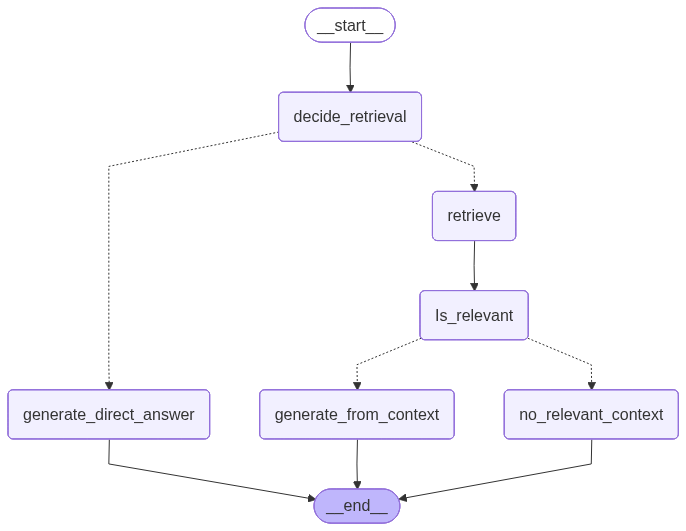

In [57]:
app

In [58]:
result = app.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "need_retrieval": False,
        "retrieved_context": [],
        "relevant_context": [],
        "answer": "",
    }
)

print(result["answer"])


No relevant context found


In [59]:
for doc in result["retrieved_context"]:
    print(doc.page_content)
    print("-"*100)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

----------------------------------------------------------------------------------------------------
NexaAI Solutions – Products & Pricing
Product Portfolio Overview
NexaAI offers a modular suite of enterprise AI products designed to help organizations manage
knowledge, analyze business data, automate customer interactions, and enforce AI governance.
Each product can be used independently or deployed as part of an integrated AI p

In [60]:
for doc in result["relevant_context"]:
    print(doc.page_content)
    print("-"*100)

In [61]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
        "need_retrieval": False,
        "retrieved_context": [],
        "relevant_context": [],
        "answer": "",
    }
)

print(result["answer"])

Aarav Mehta is the CEO of NexaAI.
